# Review Intelligence Analysis

This notebook analyzes how review behavior relates to product sales performance in an e-commerce context.

Scope: two questions only, with measurable outputs and concise visual evidence suitable for formal submission.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

## Dữ liệu đầu vào

Load `products.csv` và `reviews.csv`, sau đó tạo các biến nền tảng cần dùng cho phân tích review.

In [12]:
# 1. Load Data
df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# 2. Xử lý Doanh thu & Tương tác
df_product["revenue"] = df_product["price"] * df_product["sold_count"]

review_engagement = (
    df_review.groupby("product_id")["like_count"]
    .sum()
    .reset_index()
    .rename(columns={"like_count": "total_review_likes"})
)

df_main = pd.merge(df_product, review_engagement, on="product_id", how="left")
df_main["total_review_likes"] = df_main["total_review_likes"].fillna(0)

df_clean = df_main[(df_main["sold_count"] > 0) & (df_main["review_count"] > 0)].copy()

## Question 1
### How are review dynamics associated with product revenue and sales between 2020 and 2024?

SMART objective

- Specific: assess recency, review volume, review length, and likes in relation to revenue and sold count.
- Measurable: use Spearman correlation and distribution plots.
- Achievable: rely on available product and review tables.
- Relevant: review behavior is a key demand signal in online marketplaces.
- Time-bound: emphasize the 2020-2024 period in time-series visualization.

C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_8624\3087176787.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_review["review_month"] = df_review["review_date"].dt.to_period("M").dt.to_timestamp()
C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_8624\3087176787.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_time_analysis, x="review_count_bin", y="likes_per_review", palette="Set2", ax=axes[1, 1])


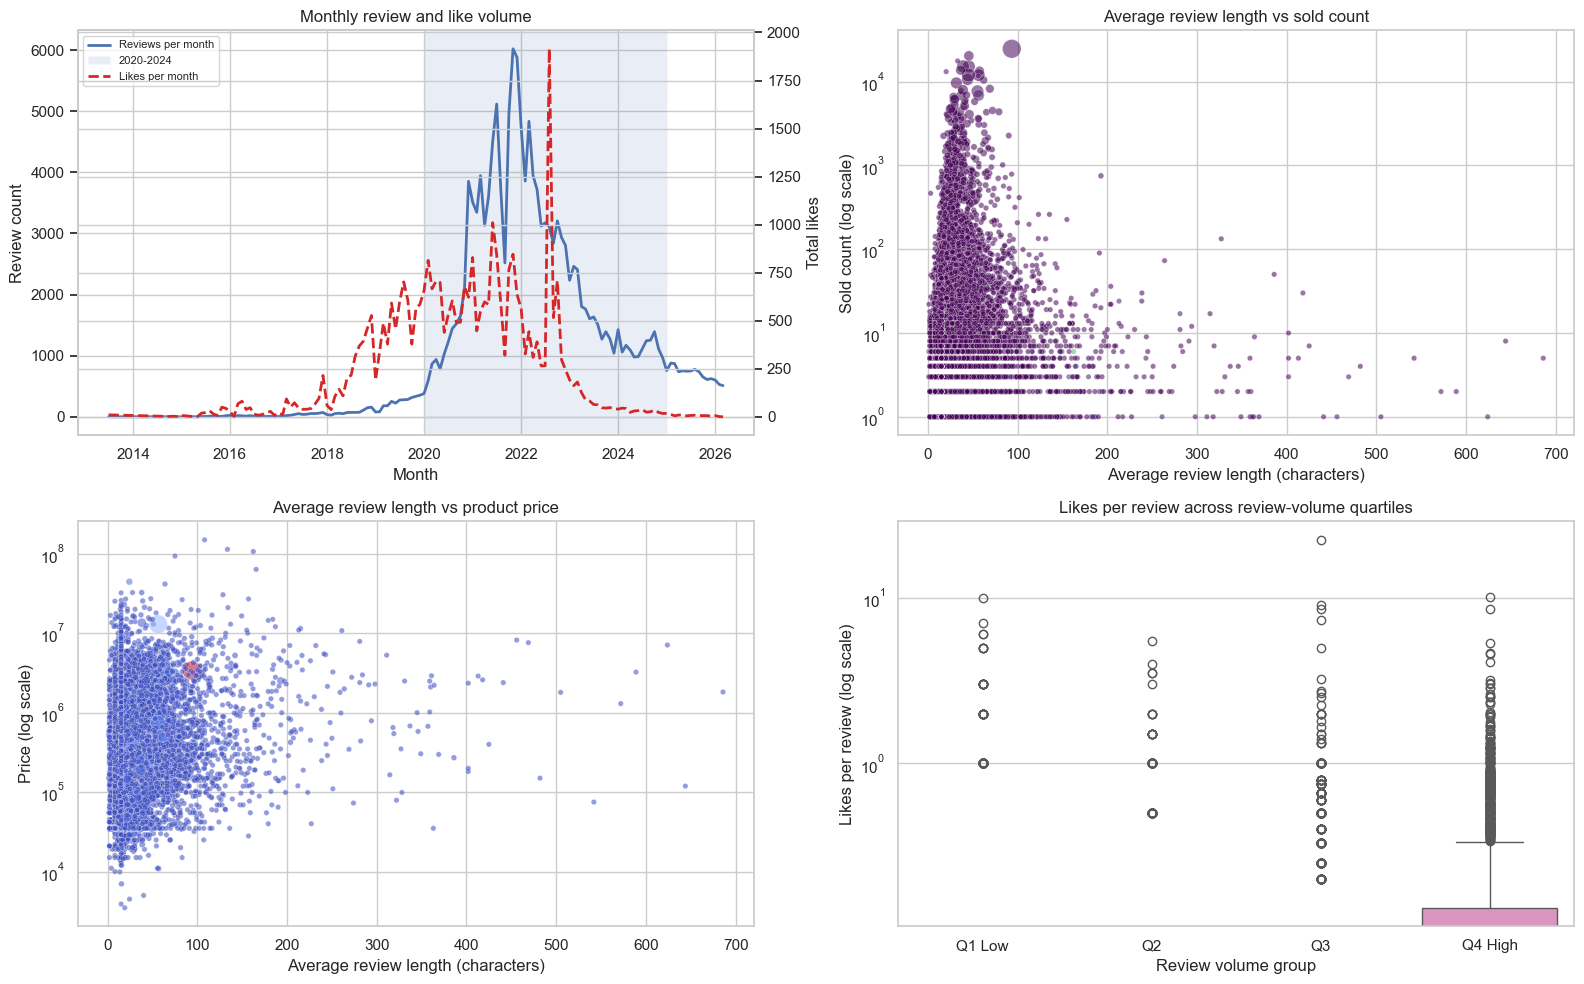

Spearman(review_count, log(revenue)): 0.654
Spearman(review_count, log(sold_count)): 0.831
Spearman(avg_review_length, log(sold_count)): 0.234
Spearman(avg_review_length, log(price)): 0.178
Review volume share in 2020-2024: 90.5%
Median likes/review ratio (Q4 vs Q1): 0.00x


In [ ]:
# Question 1: review dynamics vs sales outcomes

# Load and prepare
df_review = pd.read_csv("../data/reviews.csv")
df_product = pd.read_csv("../data/products.csv")

df_review["review_date"] = pd.to_datetime(df_review["review_date"], errors="coerce")
df_review["like_count"] = pd.to_numeric(df_review["like_count"], errors="coerce").fillna(0)
df_review["review_length"] = df_review["review_text"].astype(str).str.len()

df_product["price"] = pd.to_numeric(df_product["price"], errors="coerce").fillna(0)
df_product["sold_count"] = pd.to_numeric(df_product["sold_count"], errors="coerce").fillna(0)
df_product["review_count"] = pd.to_numeric(df_product["review_count"], errors="coerce").fillna(0)
df_product["revenue"] = df_product["price"] * df_product["sold_count"]

# Time features
current_date = df_review["review_date"].max()
df_review["days_since_review"] = (current_date - df_review["review_date"]).dt.days
df_review["review_month"] = df_review["review_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
df_review["time_weight"] = np.exp(-np.log(2) * df_review["days_since_review"] / 30)

# Product-level review aggregates
product_review_features = df_review.groupby("product_id").agg(
    weighted_review_count=("review_id", lambda x: np.sum(df_review.loc[x.index, "time_weight"])),
    avg_review_length=("review_length", "mean"),
    total_review_likes=("like_count", "sum"),
    total_reviews_from_review_table=("review_id", "count"),
).reset_index()

df_time_analysis = pd.merge(
    df_product[["product_id", "revenue", "sold_count", "price", "review_count"]],
    product_review_features,
    on="product_id",
    how="inner",
)
df_time_analysis = df_time_analysis[df_time_analysis["revenue"] > 0].copy()
df_time_analysis["likes_per_review"] = (
    df_time_analysis["total_review_likes"] / df_time_analysis["total_reviews_from_review_table"].replace(0, np.nan)
).fillna(0)
df_time_analysis["review_count_bin"] = pd.qcut(
    df_time_analysis["total_reviews_from_review_table"].rank(method="first"),
    q=4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"],
)

# Monthly summary and highlight window
monthly_review = df_review.groupby("review_month").agg(
    review_count=("review_id", "count"),
    total_like_count=("like_count", "sum"),
).reset_index().sort_values("review_month")

window = monthly_review[
    (monthly_review["review_month"] >= "2020-01-01")
    & (monthly_review["review_month"] <= "2024-12-31")
]
share_spike_period = (window["review_count"].sum() / max(1, monthly_review["review_count"].sum())) * 100

# Visuals
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Time series: review volume and likes
axes[0, 0].plot(monthly_review["review_month"], monthly_review["review_count"], linewidth=2, label="Reviews per month")
axes[0, 0].axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2024-12-31"), alpha=0.12, label="2020-2024")
ax2 = axes[0, 0].twinx()
ax2.plot(monthly_review["review_month"], monthly_review["total_like_count"], linewidth=2, linestyle="--", color="tab:red", label="Likes per month")
axes[0, 0].set_title("Monthly review and like volume")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Review count")
ax2.set_ylabel("Total likes")
ln1, lb1 = axes[0, 0].get_legend_handles_labels()
ln2, lb2 = ax2.get_legend_handles_labels()
axes[0, 0].legend(ln1 + ln2, lb1 + lb2, loc="upper left", fontsize=8)

# 2) Review text length vs sold count
sns.scatterplot(
    data=df_time_analysis,
    x="avg_review_length",
    y="sold_count",
    hue="price",
    size="review_count",
    sizes=(15, 180),
    alpha=0.55,
    palette="viridis",
    ax=axes[0, 1],
)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Average review length vs sold count")
axes[0, 1].set_xlabel("Average review length (characters)")
axes[0, 1].set_ylabel("Sold count (log scale)")
if axes[0, 1].get_legend() is not None:
    axes[0, 1].get_legend().remove()

# 3) Review text length vs price
sns.scatterplot(
    data=df_time_analysis,
    x="avg_review_length",
    y="price",
    hue="sold_count",
    size="total_reviews_from_review_table",
    sizes=(15, 180),
    alpha=0.55,
    palette="coolwarm",
    ax=axes[1, 0],
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Average review length vs product price")
axes[1, 0].set_xlabel("Average review length (characters)")
axes[1, 0].set_ylabel("Price (log scale)")
if axes[1, 0].get_legend() is not None:
    axes[1, 0].get_legend().remove()

# 4) Why likes are not proportional to review count
sns.boxplot(
    data=df_time_analysis,
    x="review_count_bin",
    y="likes_per_review",
    hue="review_count_bin",
    palette="Set2",
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Likes per review across review-volume quartiles")
axes[1, 1].set_xlabel("Review volume group")
axes[1, 1].set_ylabel("Likes per review (log scale)")

plt.tight_layout()
plt.show()

# Metrics for markdown interpretation
corr_review_revenue = df_time_analysis["total_reviews_from_review_table"].corr(np.log1p(df_time_analysis["revenue"]), method="spearman")
corr_review_sold = df_time_analysis["total_reviews_from_review_table"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman")
corr_text_sold = df_time_analysis["avg_review_length"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman")
corr_text_price = df_time_analysis["avg_review_length"].corr(np.log1p(df_time_analysis["price"]), method="spearman")
median_lpr = df_time_analysis.groupby("review_count_bin")["likes_per_review"].median().round(3)
q4_vs_q1 = median_lpr.iloc[-1] / max(median_lpr.iloc[0], 1e-9)

print(f"Spearman(review_count, log(revenue)): {corr_review_revenue:.3f}")
print(f"Spearman(review_count, log(sold_count)): {corr_review_sold:.3f}")
print(f"Spearman(avg_review_length, log(sold_count)): {corr_text_sold:.3f}")
print(f"Spearman(avg_review_length, log(price)): {corr_text_price:.3f}")
print(f"Review volume share in 2020-2024: {share_spike_period:.1f}%")
print(f"Median likes/review ratio (Q4 vs Q1): {q4_vs_q1:.2f}x")

### Interpretation Notes (Question 1)

- Review volume is strongly associated with market outcomes.
  Spearman(review_count, log(revenue)) = 0.654 and Spearman(review_count, log(sold_count)) = 0.831.
- Review text length has a positive but weaker association with outcomes.
  Spearman(avg_review_length, log(sold_count)) = 0.234 and Spearman(avg_review_length, log(price)) = 0.178.
- Review activity is concentrated in 2020-2024.
  This period contributes 90.5% of monthly review volume in the dataset.
- Likes are not proportional to review volume.
  Median likes per review in Q4 (highest review-volume group) is near zero relative to Q1, which indicates that more reviews do not automatically mean more helpful engagement per review.
- Practical implication: prioritize review quality (informativeness and usefulness) over review quantity alone.

## Question 2
### Which review attributes matter globally and which vary by category context?

SMART objective

- Specific: compare global vs category-level effects of review attributes.
- Measurable: standardized linear coefficients, mean likes by rating, and top-liked review samples.
- Achievable: aggregate review features at product level and segment by category.
- Relevant: supports actionable review-quality strategy by category.
- Time-bound: evaluated on the current dataset snapshot.

Question 2 - Cell 1: Building global and category-level models


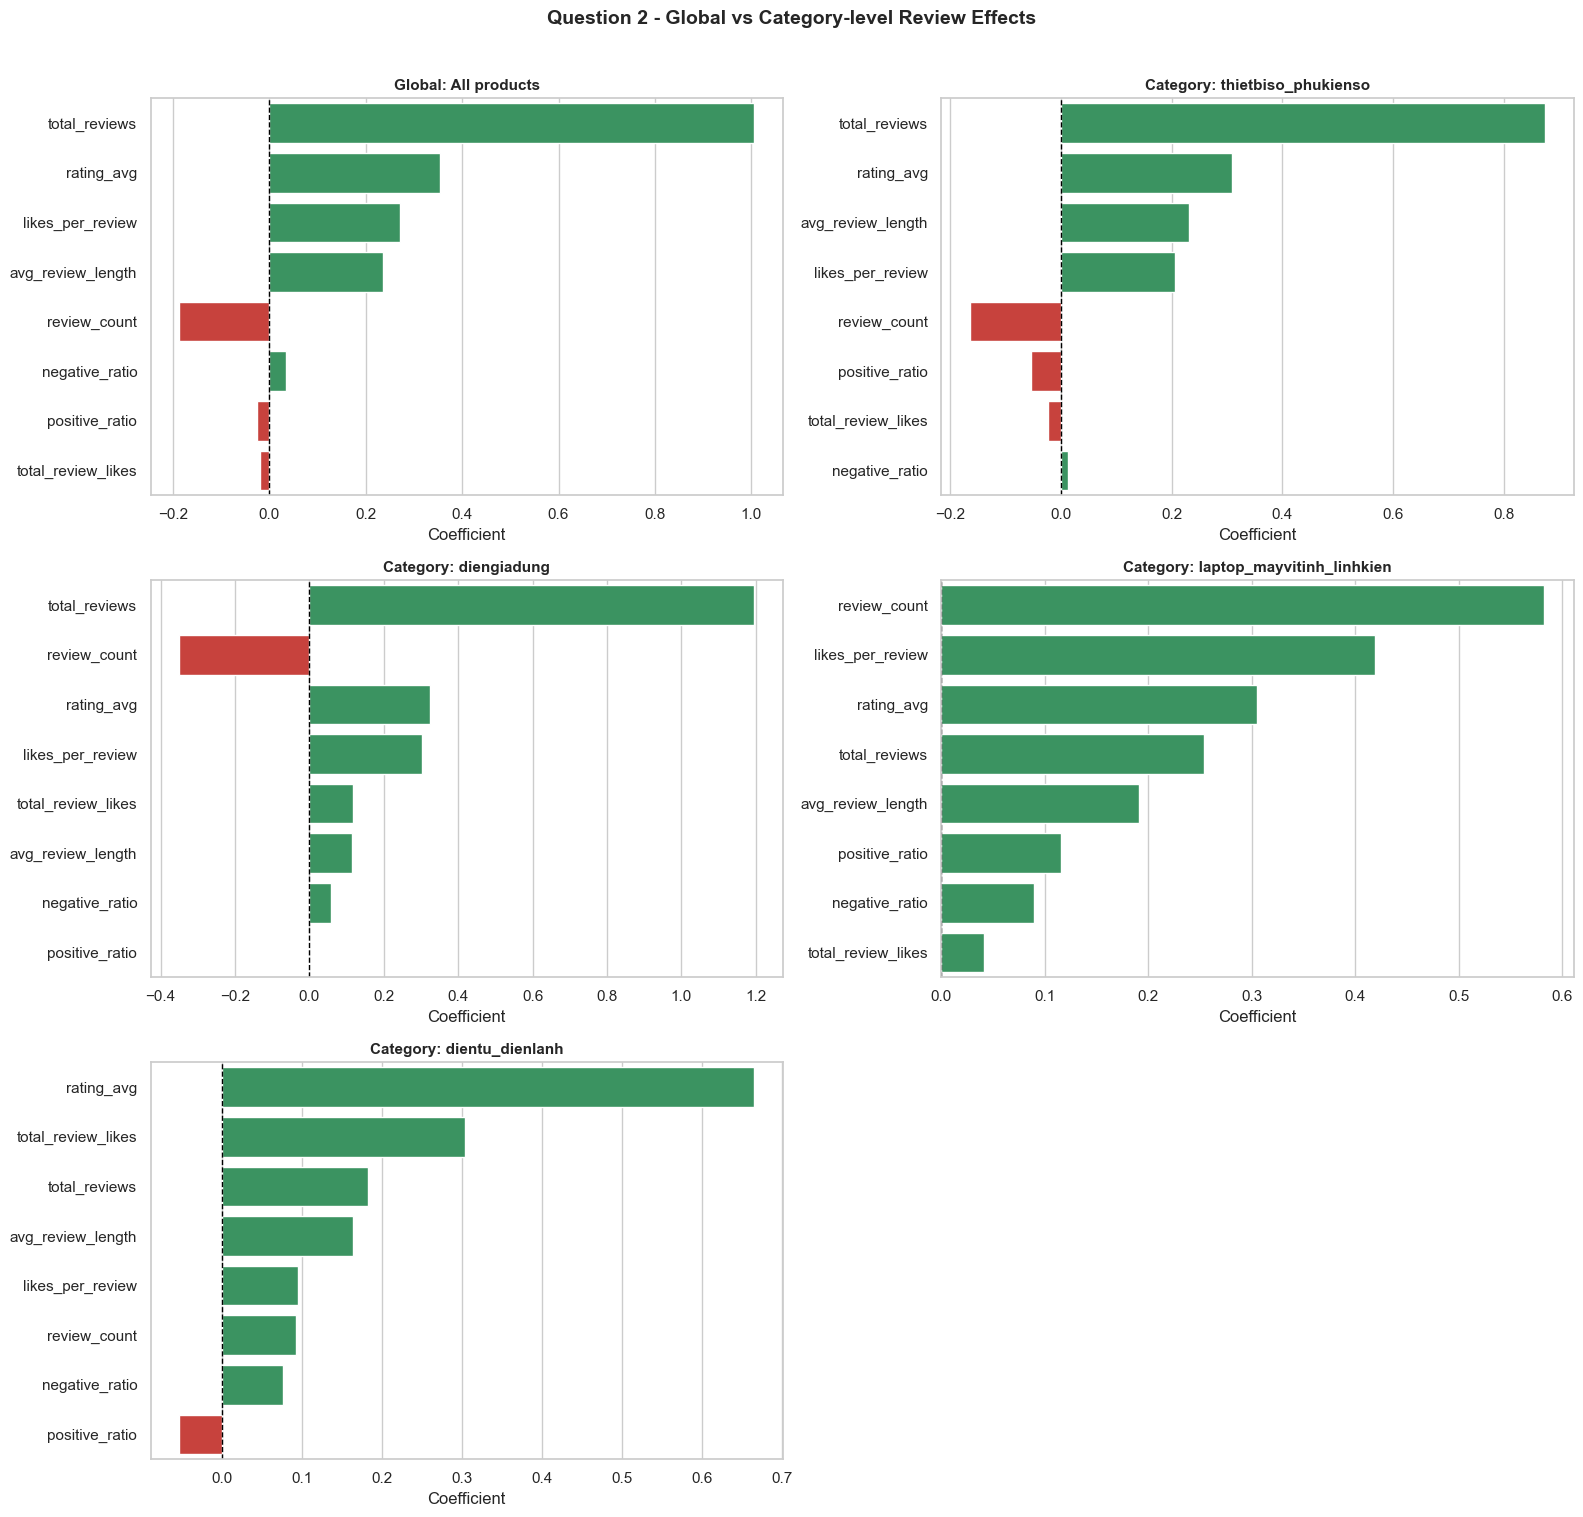

Cell 1 complete: variables available -> df_top_products, top1_names, local_weights_dict


In [14]:
# Question 2 - Cell 1: global vs local feature effects

print("Question 2 - Cell 1: Building global and category-level models")

# Standardize key fields
df_review["product_id"] = df_review["product_id"].astype(str)
df_product["product_id"] = df_product["product_id"].astype(str)

for col in ["price", "sold_count", "rating_avg", "review_count"]:
    df_product[col] = pd.to_numeric(df_product[col], errors="coerce").fillna(0)

df_product["revenue"] = df_product["price"] * df_product["sold_count"]
df_review["like_count"] = pd.to_numeric(df_review["like_count"], errors="coerce").fillna(0)
df_review["review_length"] = df_review["review_text"].astype(str).str.len()

pos_words = ["tốt", "tuyệt", "đẹp", "xịn", "ok", "ngon", "đỉnh", "chất", "hài lòng", "ưng", "chuẩn", "nhanh"]
neg_words = ["tệ", "chán", "lỗi", "hỏng", "móp", "xước", "dỏm", "kém", "thất vọng", "chậm", "trầy", "vỡ"]

def text_sentiment_score(text):
    t = str(text).lower()
    pos = sum(t.count(w) for w in pos_words)
    neg = sum(t.count(w) for w in neg_words)
    if pos > neg:
        return 1
    if neg > pos:
        return -1
    return 0

df_review["sentiment"] = df_review["review_text"].apply(text_sentiment_score)

review_features = df_review.groupby("product_id", as_index=False).agg(
    total_reviews=("review_id", "count"),
    total_review_likes=("like_count", "sum"),
    avg_review_length=("review_length", "mean"),
    positive_ratio=("sentiment", lambda x: (x == 1).mean()),
    negative_ratio=("sentiment", lambda x: (x == -1).mean()),
)
review_features["likes_per_review"] = review_features["total_review_likes"] / review_features["total_reviews"].replace(0, np.nan)
review_features["likes_per_review"] = review_features["likes_per_review"].fillna(0)

df_top_products = df_product.merge(review_features, on="product_id", how="inner")
df_top_products = df_top_products[df_top_products["revenue"] > 0].copy()
df_top_products["L2_ancestor"] = df_top_products["source_category"].fillna("unknown")

features = [
    "review_count",
    "total_reviews",
    "total_review_likes",
    "likes_per_review",
    "avg_review_length",
    "rating_avg",
    "positive_ratio",
    "negative_ratio",
]
for c in features:
    df_top_products[c] = pd.to_numeric(df_top_products[c], errors="coerce").fillna(0)

def get_linear_weights(df, feature_cols, target_col="revenue"):
    X = df[feature_cols]
    y = np.log1p(df[target_col])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LinearRegression()
    model.fit(X_scaled, y)
    out = pd.DataFrame({"Attribute": feature_cols, "Weight": model.coef_})
    out["Impact_Magnitude"] = out["Weight"].abs()
    return out.sort_values("Impact_Magnitude", ascending=False).reset_index(drop=True)

global_weights = get_linear_weights(df_top_products, features)
top1_names = df_top_products["L2_ancestor"].value_counts().head(4).index.tolist()

local_weights_dict = {}
for cat in top1_names:
    df_cat = df_top_products[df_top_products["L2_ancestor"] == cat]
    if len(df_cat) >= 30:
        local_weights_dict[cat] = get_linear_weights(df_cat, features)

sns.set_theme(style="whitegrid")
num_plots = 1 + len(local_weights_dict)
rows, cols = int(np.ceil(num_plots / 2)), 2
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)

def plot_weights_on_ax(ax, df_w, title, is_global=False):
    colors = ["#2ca25f" if w > 0 else "#de2d26" for w in df_w["Weight"]]
    sns.barplot(data=df_w, x="Weight", y="Attribute", palette=colors, hue="Attribute", legend=False, ax=ax)
    ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title if not is_global else f"Global: {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("")

plot_weights_on_ax(axes[0], global_weights, "All products", is_global=True)
plot_idx = 1
for cat_name, df_w in local_weights_dict.items():
    plot_weights_on_ax(axes[plot_idx], df_w, f"Category: {cat_name}")
    plot_idx += 1
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Question 2 - Global vs Category-level Review Effects", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Cell 1 complete: variables available -> df_top_products, top1_names, local_weights_dict")

Question 2 - Cell 2: Comparing likes by category and rating

Category-level likes summary


,total_products,avg_likes_per_product,median_likes_per_product,avg_reviews_per_product
L2_ancestor,,,,
diengiadung,2645,6.23,0.0,24.72
laptop_mayvitinh_linhkien,1189,4.26,0.0,16.16
thietbiso_phukienso,6395,1.70,0.0,10.65
dientu_dienlanh,289,0.71,0.0,6.16



Average likes per review by star rating


rating,1,2,3,4,5
L2_ancestor,,,,,
diengiadung,1.17,0.93,0.88,0.25,0.20
dientu_dienlanh,0.34,0.29,0.51,0.08,0.09
laptop_mayvitinh_linhkien,1.10,0.76,0.85,0.35,0.20
thietbiso_phukienso,0.37,0.38,0.40,0.12,0.14


C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_8624\3772721640.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="L2_ancestor", y="likes_per_review", palette="Set2")


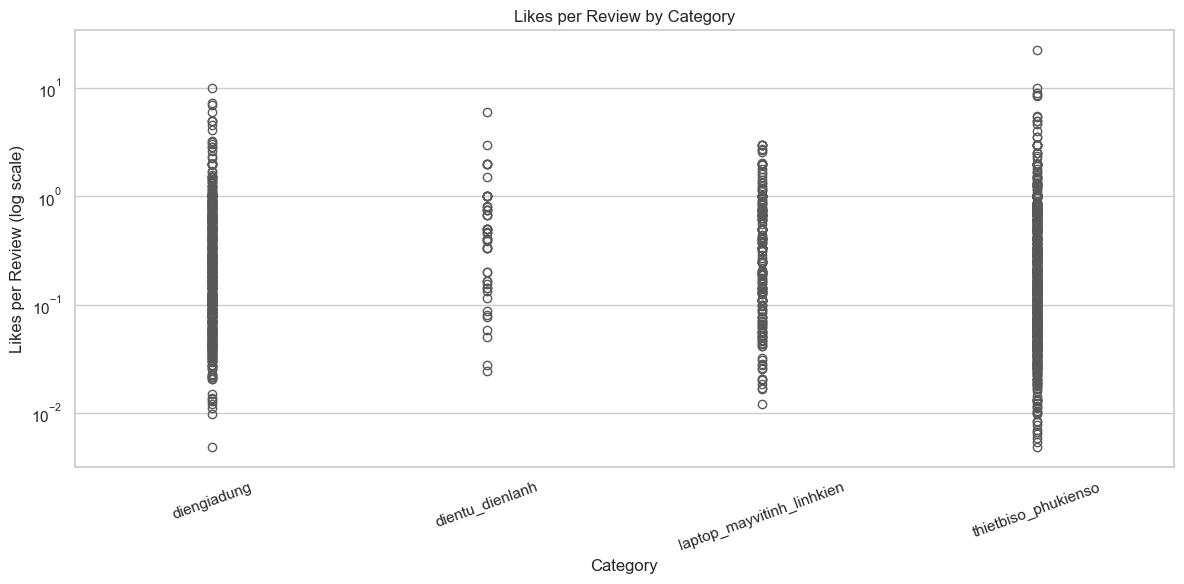

In [ ]:
# Question 2 - Cell 2: likes by category and rating

print("Question 2 - Cell 2: Comparing likes by category and rating")

likes_summary = (
    df_top_products[df_top_products["L2_ancestor"].isin(top1_names)]
    .groupby("L2_ancestor")
    .agg(
        total_products=("product_id", "count"),
        avg_likes_per_product=("total_review_likes", "mean"),
        median_likes_per_product=("total_review_likes", "median"),
        avg_reviews_per_product=("total_reviews", "mean"),
    )
    .sort_values("avg_likes_per_product", ascending=False)
)

print("\nCategory-level likes summary")
display(likes_summary.round(2))

df_review_extended = df_review.merge(
    df_product[["product_id", "source_category"]].rename(columns={"source_category": "product_source_category"}),
    on="product_id",
    how="left",
)
df_review_extended["L2_ancestor"] = df_review_extended["product_source_category"].fillna("unknown")
df_review_extended = df_review_extended[df_review_extended["L2_ancestor"].isin(top1_names)].copy()
df_review_extended["rating"] = pd.to_numeric(df_review_extended["rating"], errors="coerce")
df_review_extended["like_count"] = pd.to_numeric(df_review_extended["like_count"], errors="coerce").fillna(0)

rating_likes_corr = df_review_extended.groupby(["L2_ancestor", "rating"])["like_count"].mean().unstack()

print("\nAverage likes per review by star rating")
display(rating_likes_corr.round(2))

plot_df = df_top_products[df_top_products["L2_ancestor"].isin(top1_names)].copy()
plot_df["likes_per_review"] = plot_df["total_review_likes"] / plot_df["total_reviews"].replace(0, np.nan)
plot_df["likes_per_review"] = plot_df["likes_per_review"].fillna(0)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="L2_ancestor", y="likes_per_review", hue="L2_ancestor", palette="Set2", legend=False)
plt.yscale("log")
plt.title("Likes per Review by Category")
plt.xlabel("Category")
plt.ylabel("Likes per Review (log scale)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [16]:
# Question 2 - Cell 3: top liked reviews by category

print("Question 2 - Cell 3: Extracting top liked reviews by category\n")

df_review_full = df_review.merge(
    df_product[["product_id", "product_name", "source_category"]].rename(columns={"source_category": "product_source_category"}),
    on="product_id",
    how="left",
)

df_review_full["L2_ancestor"] = df_review_full["product_source_category"].fillna("unknown")
df_top_reviews = df_review_full[df_review_full["L2_ancestor"].isin(top1_names)].copy()

df_top_reviews["like_count"] = pd.to_numeric(df_top_reviews["like_count"], errors="coerce").fillna(0).astype(int)
df_top_reviews["rating"] = pd.to_numeric(df_top_reviews["rating"], errors="coerce")

top5_reviews_per_cat = (
    df_top_reviews.sort_values(by=["L2_ancestor", "like_count"], ascending=[True, False])
    .groupby("L2_ancestor")
    .head(5)
)

for cat in top1_names:
    print(f"Category: {cat}")
    cat_reviews = top5_reviews_per_cat[top5_reviews_per_cat["L2_ancestor"] == cat].copy()

    if cat_reviews.empty:
        print("No review data for this category.\n")
        continue

    cat_reviews["Review_Text"] = cat_reviews["review_text"].astype(str).apply(
        lambda x: x[:180] + "..." if len(x) > 180 else x
    )
    cat_reviews["Product_Name"] = cat_reviews["product_name"].astype(str).apply(
        lambda x: x[:60] + "..." if len(x) > 60 else x
    )

    cat_reviews = cat_reviews.rename(columns={"rating": "Rating", "like_count": "Likes"})
    cols_to_show = ["Rating", "Likes", "Product_Name", "Review_Text"]
    display(cat_reviews[cols_to_show].reset_index(drop=True))
    print("-" * 90)

Question 2 - Cell 3: Extracting top liked reviews by category

Category: thietbiso_phukienso


,Rating,Likes,Product_Name,Review_Text
0,5,60,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Cân nhắc lợi và hại khi mua bởi những lý do sa...
1,5,51,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Có tem nhập khẩu Ngôi nhà Đức gì đó là được rồ...
2,1,48,Chuột Chơi Game Có Dây Logitech Proteus Spectr...,Sản phẩm mình mới nhận được phải nói là rất cũ...
3,5,47,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Mình cũng lăn tăn trước khi order lắm nhưng mn...
4,3,41,Tai Nghe Nhét Tai Sony MDR-EX155AP - Hàng Chín...,"vừa nhận được hàng, mở ra thì bên trong đúng c..."


------------------------------------------------------------------------------------------
Category: diengiadung


,Rating,Likes,Product_Name,Review_Text
0,5,289,Nồi Chiên Không Dầu Điện Tử Lock&Lock EJF357BL...,Mình mua lúc trước tết. giá giảm còn 2tr2 thôi...
1,5,174,Máy Hút Bụi Cầm Tay Không Dây Damas XC628 - Ch...,"thực sự cũng không định mua hàng qua mang đâu,..."
2,5,144,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) ...,Hôm nay tình cờ thấy Tiki sale máy làm sữa chu...
3,5,125,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) ...,Làm xong đi giới thiệu bà chị bả mua liền xong...
4,3,110,Máy Cạo Râu Mạnh Mẽ Tiện Dụng Phong Cách SCW301U,Hàng thì hài lòng nhưng shiper mình k hài lòng...


------------------------------------------------------------------------------------------
Category: laptop_mayvitinh_linhkien


,Rating,Likes,Product_Name,Review_Text
0,1,73,TP-Link TL-WN822N - USB Wifi (high gain) chuẩ...,Mình là người làm kỹ thuật cũng có liên quan đ...
1,1,55,Thiết Bị Kích Sóng Wifi Xiaomi Pro - Đen - Hàn...,"Thứ nhất,sản phẩm không dùng được.Thứ hai,đội ..."
2,4,49,TP-Link TL-WR841N - Router Wifi Chuẩn N Tốc Đ...,Mình mua lần đầu lỗi rớt mạng đổi luôn. Sau kh...
3,3,47,Máy In Laser Đơn Năng Canon LBP 6030 - Hàng ch...,"Giao hàng nhanh, hàng chính hãng canon được sả..."
4,5,45,Phần mềm Microsoft 365 Personal | 12 tháng | ...,"ok, tôi cảm thấy thích thú khi đã gia hạn thêm..."


------------------------------------------------------------------------------------------
Category: dientu_dienlanh


,Rating,Likes,Product_Name,Review_Text
0,3,12,Android TV Box TX3 mini phiên bản 2020 Android...,Mẫu này cài android 9.0 nhé không phải android...
1,5,10,Tủ lạnh mini Kemin Chính hãng 10L,Tủ lạnh hoạt động tốt như mô tả. Gia đình chún...
2,5,6,Android tivi box x96 max 4GB RAM wifi kép có đ...,sản phẩm tốt. nhưng dịch vụ rất tệ tặng chuột ...
3,5,6,Tủ Lạnh Inverter Sharp SJ-FX688VG-BK (605L) - ...,Rất ok máy chạy rats êm. Tủ to đựng được rất n...
4,1,5,Android TV Box TX3 mini phiên bản 2020 Android...,Sản phẩm rất tệ. Bật wifi miết ko được. Điều k...


------------------------------------------------------------------------------------------


### Interpretation Notes (Question 2)

- Global model: the largest positive contributors are total_reviews and rating_avg, while review_count alone can turn negative after controlling for other variables.
- Local model variation exists across categories.
  In some categories, likes_per_review and avg_review_length become more important than in the global model.
- Likes by rating are asymmetric.
  In multiple categories, low-star reviews (1-2 stars) receive higher average likes than high-star reviews (4-5 stars), suggesting users engage more with problem-focused feedback.
- Category-level boxplot confirms non-linearity.
  Categories with high review volume do not consistently have high likes per review.
- Qualitative evidence from top-liked reviews supports the quantitative pattern.
  Most highly liked reviews are detailed, experience-based, and problem-solving rather than short generic praise.
- Practical implication: optimize for review usefulness and diagnostic value by category, not just for review count growth.